<a href="https://colab.research.google.com/github/skrudgemacdac/ArchitectLesson1/blob/master/DDColor_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%cd /content
!git clone -b dev https://github.com/camenduru/DDColor

!apt -y install -qq aria2
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/camenduru/cv_ddcolor_image-colorization/resolve/main/pytorch_model.pt -d /content/DDColor/models -o pytorch_model.pt

!wget https://modelscope.oss-cn-beijing.aliyuncs.com/test/images/audrey_hepburn.jpg -O /content/DDColor/in.jpg
!pip install -q timm

%cd /content/DDColor

!sed -i 's/from \.version import __gitsha__, __version__/# from \.version import __gitsha__, __version__/' /content/DDColor/basicsr/__init__.py

import argparse
import cv2
import numpy as np
import os
from tqdm import tqdm
import torch
from basicsr.archs.ddcolor_arch import DDColor
import torch.nn.functional as F

class ImageColorizationPipeline(object):

    def __init__(self, model_path, input_size=256, model_size='large'):

        self.input_size = input_size
        if torch.cuda.is_available():
            self.device = torch.device('cuda')
        else:
            self.device = torch.device('cpu')

        if model_size == 'tiny':
            self.encoder_name = 'convnext-t'
        else:
            self.encoder_name = 'convnext-l'

        self.decoder_type = "MultiScaleColorDecoder"

        if self.decoder_type == 'MultiScaleColorDecoder':
            self.model = DDColor(
                encoder_name=self.encoder_name,
                decoder_name='MultiScaleColorDecoder',
                input_size=[self.input_size, self.input_size],
                num_output_channels=2,
                last_norm='Spectral',
                do_normalize=False,
                num_queries=100,
                num_scales=3,
                dec_layers=9,
            ).to(self.device)
        else:
            self.model = DDColor(
                encoder_name=self.encoder_name,
                decoder_name='SingleColorDecoder',
                input_size=[self.input_size, self.input_size],
                num_output_channels=2,
                last_norm='Spectral',
                do_normalize=False,
                num_queries=256,
            ).to(self.device)

        self.model.load_state_dict(
            torch.load(model_path, map_location=torch.device('cpu'))['params'],
            strict=False)
        self.model.eval()

    @torch.no_grad()
    def process(self, img):
        self.height, self.width = img.shape[:2]
        # print(self.width, self.height)
        # if self.width * self.height < 100000:
        #     self.input_size = 256

        img = (img / 255.0).astype(np.float32)
        orig_l = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)[:, :, :1]  # (h, w, 1)

        # resize rgb image -> lab -> get grey -> rgb
        img = cv2.resize(img, (self.input_size, self.input_size))
        img_l = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)[:, :, :1]
        img_gray_lab = np.concatenate((img_l, np.zeros_like(img_l), np.zeros_like(img_l)), axis=-1)
        img_gray_rgb = cv2.cvtColor(img_gray_lab, cv2.COLOR_LAB2RGB)

        tensor_gray_rgb = torch.from_numpy(img_gray_rgb.transpose((2, 0, 1))).float().unsqueeze(0).to(self.device)
        output_ab = self.model(tensor_gray_rgb).cpu()  # (1, 2, self.height, self.width)

        # resize ab -> concat original l -> rgb
        output_ab_resize = F.interpolate(output_ab, size=(self.height, self.width))[0].float().numpy().transpose(1, 2, 0)
        output_lab = np.concatenate((orig_l, output_ab_resize), axis=-1)
        output_bgr = cv2.cvtColor(output_lab, cv2.COLOR_LAB2BGR)

        output_img = (output_bgr * 255.0).round().astype(np.uint8)

        return output_img

colorizer = ImageColorizationPipeline(model_path='/content/DDColor/models/pytorch_model.pt', input_size=512)

# helper function taken from: https://huggingface.co/blog/stable_diffusion
from PIL import Image
def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols

    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    grid_w, grid_h = grid.size

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid

/content
fatal: destination path 'DDColor' already exists and is not an empty directory.
aria2 is already the newest version (1.36.0-1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.

Download Results:
gid   |stat|avg speed  |path/URI
======+====+===========+=======================================================
afff1f|OK  |       0B/s|/content/DDColor/models/pytorch_model.pt

Status Legend:
(OK):download completed.
--2026-06-20 18:51:03--  https://modelscope.oss-cn-beijing.aliyuncs.com/test/images/audrey_hepburn.jpg
Resolving modelscope.oss-cn-beijing.aliyuncs.com (modelscope.oss-cn-beijing.aliyuncs.com)... 101.226.36.211
Connecting to modelscope.oss-cn-beijing.aliyuncs.com (modelscope.oss-cn-beijing.aliyuncs.com)|101.226.36.211|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 97191 (95K) [image/jpeg]
Saving to: ‘/content/DDColor/in.jpg’

/content/DDColor/in 100%[===================>]  94.91K  --.-KB/s    in 0.07s   

2026-06-20 18:51:04 (1.

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


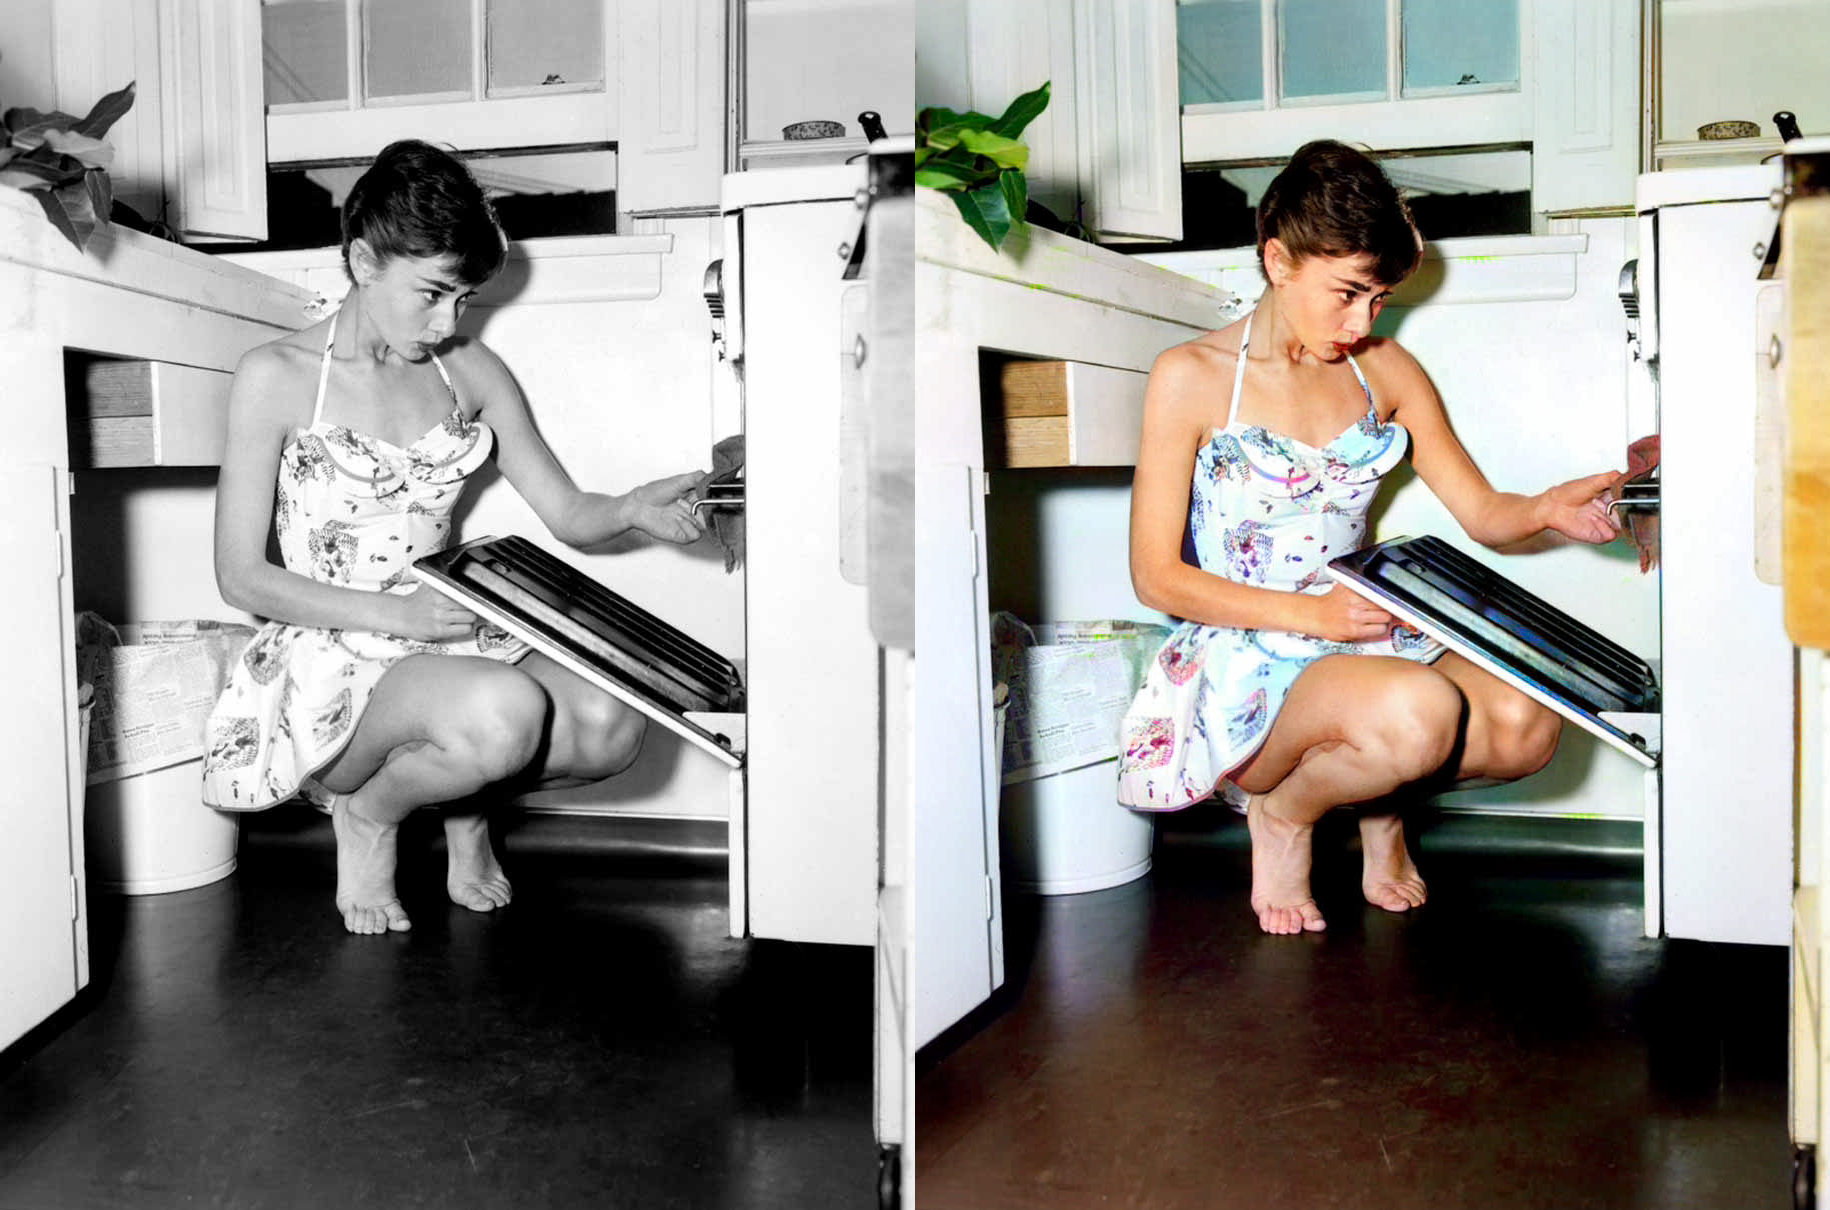

In [2]:
image_in = cv2.imread('/content/DDColor/in.jpg')
image_out = colorizer.process(image_in)
cv2.imwrite('/content/DDColor/out.jpg', image_out)
image_in_pil = Image.fromarray(cv2.cvtColor(image_in, cv2.COLOR_BGR2RGB))
image_out_pil = Image.fromarray(cv2.cvtColor(image_out, cv2.COLOR_BGR2RGB))
images = [image_in_pil, image_out_pil]
grid = image_grid(images, rows=1, cols=2)
grid

In [3]:
from google.colab import files
uploaded = files.upload()

Saving test1.mp4 to test1.mp4


In [ ]:
import cv2
import torch
from tqdm import tqdm
import numpy as np

from DDColor.ddcolor.model import DDColor

# Settings
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load model
model = DDColor(encoder_name='convnext-t').to(device)
checkpoint_path = "/content/DDColor/models/pytorch_model.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint)
model.eval()
print("Model loaded successfully!")

# ====================== VIDEO COLORIZATION ======================

input_path = "/content/drive/MyDrive/test1.mp4"   # ← ИЗМЕНИ НА СВОЙ ПУТЬ К ВИДЕО
output_path = "/content/test1_color.mp4"

cap = cv2.VideoCapture(input_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Video info: {width}x{height}, {fps} fps, {total_frames} frames")

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

with torch.no_grad():
    for _ in tqdm(range(total_frames), desc="Colorizing frames"):
        ret, frame = cap.read()
        if not ret:
            break

        # Convert to LAB
        lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
        l = lab[:, :, 0].astype("float32") / 255.0

        # Prepare for model
        l_resized = cv2.resize(l, (512, 512))
        l_tensor = torch.from_numpy(l_resized).unsqueeze(0).unsqueeze(0).to(device)
        l_tensor = (l_tensor - 0.5) * 2.0

        # Inference
        ab = model(l_tensor)
        ab = ab.squeeze().cpu().numpy()
        ab = cv2.resize(ab.transpose(1, 2, 0), (width, height))

        # Merge channels
        lab_out = lab.copy()
        lab_out[:, :, 1:] = (ab * 128).astype("uint8")
        colorized = cv2.cvtColor(lab_out, cv2.COLOR_LAB2BGR)

        out.write(colorized)

cap.release()
out.release()

print("Colorization completed successfully!")
print("Output saved to:", output_path)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
